# Previsão de Incidentes D+1 e D+7 **por Cluster Operacional**

**Projeto PredictOps — Equipe Dataway | Challenge Locaweb + FIAP 2026**

---

## Por que este modelo existe

Os modelos anteriores (`d1_d7.ipynb`) preveem o **volume total** de incidentes.
O problema é que "1.200 incidentes amanhã" não é uma informação completa: 63% da base
é ruído de monitoramento que fecha sozinho, e o gestor não consegue distinguir o que
exige gente do que não exige.

Este notebook resolve isso decompondo a previsão nos **três regimes operacionais**
identificados pela clusterização (`cluster1.ipynb`):

| Cluster | Nome operacional | Volume | Perfil |
|---|---|---|---|
| 0 | **Ruído de monitoramento** | 77.719 (63,4%) | 100% monitoramento, 71% P4 |
| 1 | **Operação geral** | 31.494 (25,7%) | 49% manual, P3 dominante |
| 2 | **Cauda crítica** | 13.330 (10,9%) | 29% P2, categorias específicas |

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor,
                              HistGradientBoostingRegressor)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

In [ ]:
ARQUIVO = Path("LW-DATASET-TRATADO.xlsx")
SEED = 42
DATA_INICIO = "2025-01-01"
FRAC_TESTE   = 0.20  # últimos 20% da série = janela cega
K_FINAL = 3 # definido no cluster.ipynb (Elbow + Silhouette 0,4648)
SAIDA = Path(".") 

np.random.seed(SEED)

Recorte: a partir de 2025-01-01 | janela cega: 20% | seed: 42


In [3]:
df = pd.read_excel(ARQUIVO)
df["Aberto"] = pd.to_datetime(df["Aberto"], errors="coerce")

print("Arquivo:", ARQUIVO.name)
print("Registros:", f"{len(df):,}".replace(",", "."), "| Colunas:", df.shape[1])
print("Período:", df["Aberto"].min().date(), "a", df["Aberto"].max().date())
df[["Número", "Prioridade", "Produto", "Aberto por", "Aberto"]].head(3)

Arquivo: LW-DATASET-TRATADO.xlsx
Registros: 122.543 | Colunas: 28
Período: 2023-01-02 a 2025-12-31


,Número,Prioridade,Produto,Aberto por,Aberto
0,INC8654273,3 - Média,MONITORING_AUTO,Monitoramento,2025-12-31 23:45:18
1,INC8654270,4 - Baixa,MONITORING_AUTO,Monitoramento,2025-12-31 23:39:36
2,INC8654264,4 - Baixa,MONITORING_AUTO,Monitoramento,2025-12-31 23:23:10


**Duas features de apoio, criadas antes de tudo:**

- `mes`
- `tem_AM`: alerta *Application Monitoring*. É a variável que capturou a virada
  de processo de setembro/2025.

In [4]:
df["mes"] = df["Aberto"].dt.month
df["tem_AM"] = (df["Descrição resumida"]
                .str.contains("Application Monitoring", case=False, na=False)
                .astype(int))

print("Incidentes com alerta Application Monitoring:",
      f"{df['tem_AM'].sum():,}".replace(",", "."),
      f"({df['tem_AM'].mean() * 100:.1f}% da base)")

Incidentes com alerta Application Monitoring: 35.609 (29.1% da base)


## 3. Reconstrução dos clusters operacionais

Reproduzo aqui o pipeline do `cluster1.ipynb` === mesmas features

### 3.1 Redução de cardinalidade

`Categoria` tem 143 valores e `Subcategoria` tem 450. Sem agrupar a cauda em `OUTROS`, o
one-hot geraria centenas de colunas quase vazias, e no K-Means isso distorce as distâncias:
duas linhas ficam "parecidas" só por serem zero em quase tudo.

`1 - Crítica` aparece **uma única vez** na base inteira, então vai junto com `2 - Alta`.

In [5]:
dfc = df.copy()
dfc["hora_abertura"] = dfc["Aberto"].dt.hour
dfc["dia_semana"]    = dfc["Aberto"].dt.dayofweek
dfc["fim_de_semana"] = (dfc["dia_semana"] >= 5).astype(int)

# cauda longa agrupada em OUTROS
for col, novo, n_top in [("Item de configuração", "Item_config_cluster", 100),
                         ("Categoria",            "Categoria_cluster",    30),
                         ("Subcategoria",         "Subcategoria_cluster", 30)]:
    top = dfc[col].value_counts().head(n_top).index
    dfc[novo] = dfc[col].where(dfc[col].isin(top), "OUTROS")
    print(f"{col:22s} {dfc[col].nunique():4d} valores -> {dfc[novo].nunique():3d} após agrupar")

dfc["Prioridade_cluster"] = dfc["Prioridade"].replace({"1 - Crítica": "2 - Alta"})

Item de configuração   9172 valores -> 101 após agrupar
Categoria               143 valores ->  31 após agrupar
Subcategoria            450 valores ->  31 após agrupar


### 3.2 Matriz de features e K-Means

One-hot nas categóricas, `StandardScaler` em tudo

In [6]:
COLS_CAT = ["Prioridade_cluster", "Produto", "Categoria_cluster", "Subcategoria_cluster",
            "Grupo designado", "Item_config_cluster", "Aberto por"]
FEATS_CLUSTER = COLS_CAT + ["hora_abertura", "dia_semana", "fim_de_semana", "mes", "tem_AM"]

X = pd.get_dummies(dfc[FEATS_CLUSTER], columns=COLS_CAT, drop_first=False)
X_scaled = StandardScaler().fit_transform(X)

print("Matriz para clusterização:", X_scaled.shape)

Matriz para clusterização: (122543, 244)


In [7]:
kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(df["cluster"].value_counts().sort_index().to_string())

cluster
0    77719
1    31494
2    13330


### 3.3 Nomear os clusters pelo perfil, não pelo número

- o maior em volume é o **Ruído de monitoramento**;
- entre os dois restantes, o de maior % de P2 é a **Cauda crítica**;
- o que sobra é a **Operação geral**.

In [8]:
perfil = (df.groupby("cluster")
            .agg(incidentes=("Número", "size"),
                 pct_P2=("Prioridade", lambda s: (s == "2 - Alta").mean() * 100),
                 pct_manual=("Aberto por", lambda s: (s == "Manual").mean() * 100),
                 pct_com_AM=("tem_AM", lambda s: s.mean() * 100)))

maior   = perfil["incidentes"].idxmax()                      # ruído: domina o volume
critico = perfil.drop(index=maior)["pct_P2"].idxmax()        # cauda: maior % de alta prioridade

NOMES_CLUSTER = {int(maior): "Ruído de monitoramento", int(critico): "Cauda crítica"}
for c in perfil.index:
    NOMES_CLUSTER.setdefault(int(c), "Operação geral")
NOMES_CLUSTER = {c: NOMES_CLUSTER[c] for c in sorted(NOMES_CLUSTER)}

df["cluster_nome"] = df["cluster"].map(NOMES_CLUSTER)

resumo = perfil.reset_index()
resumo["cluster_nome"] = resumo["cluster"].map(NOMES_CLUSTER)
resumo["pct_base"] = resumo["incidentes"] / len(df) * 100
resumo = resumo[["cluster", "cluster_nome", "incidentes", "pct_base",
                 "pct_P2", "pct_manual", "pct_com_AM"]]
resumo.round(1)

,cluster,cluster_nome,incidentes,pct_base,pct_P2,pct_manual,pct_com_AM
0,0,Ruído de monitoramento,77719,63.4,7.1,0.0,44.9
1,1,Operação geral,31494,25.7,20.1,48.9,2.2
2,2,Cauda crítica,13330,10.9,28.8,21.4,0.0


Os volumes batem com o `cluster1.ipynb`.

- **Ruído de monitoramento**: 100% aberto por automação e quase nada de P2
- **Operação geral**: quase metade aberta manualmente
- **Cauda crítica**: o menor em volume e o maior em criticidade

## 4. Séries diárias por regime

Aqui muda a unidade de análise: de **incidente** para **dia × cluster**.

Três decisões que mudam o resultado:

1. **Calendário completo.** Reindexo em todos os dias do período e preencho lacunas com
   zero === dia sem incidente é válido, não dado faltante
2. **`tem_AM` por dia** é a proporção de incidentes daquele dia com alerta de Application
   Monitoring
3. **Sem vazamento.** As features do dia `t` usam só informação disponível até `t`; os
   alvos são `t+1` e `t+7`.

In [10]:
FEATURES   = ["lag_1", "lag_7", "media_7d", "tem_AM", "mes", "dia_semana"]
COLS_NAIVE = ["qtd_incidentes"]   # coluna que os estimadores ingênuos consomem

base = df[df["Aberto"] >= DATA_INICIO].copy()
base["data"] = base["Aberto"].dt.normalize()
CALENDARIO = pd.date_range(base["data"].min(), base["data"].max(), freq="D")

print("Período modelado:", CALENDARIO.min().date(), "a", CALENDARIO.max().date(),
      f"({len(CALENDARIO)} dias)")

Período modelado: 2025-01-01 a 2025-12-31 (365 dias)


In [11]:
def montar_serie(sub: pd.DataFrame) -> pd.DataFrame:
    """Série diária de contagem + features temporais, sem vazamento.

    Recebe o recorte de incidentes de um cluster (ou a base toda) e devolve uma linha por
    dia do CALENDARIO, com as features conhecidas em `t` e os alvos em `t+1` e `t+7`.
    """
    g = sub.groupby("data")
    s = (pd.DataFrame({"qtd_incidentes": g.size(), "tem_AM": g["tem_AM"].mean()})
           .reindex(CALENDARIO).fillna(0))
    s.index.name = "data"
    s = s.reset_index()

    q = s["qtd_incidentes"]
    s["lag_1"]    = q.shift(1)            # ontem
    s["lag_7"]    = q.shift(7)            # mesmo dia da semana anterior
    s["media_7d"] = q.rolling(7).mean()   # nível da última semana (inclui hoje; o alvo é t+1)

    s["mes"]        = s["data"].dt.month
    s["dia_semana"] = s["data"].dt.dayofweek

    s["target_d1"] = q.shift(-1)
    s["target_d7"] = q.shift(-7)
    return s

In [12]:
series = {nome: montar_serie(base[base["cluster"] == c])
          for c, nome in NOMES_CLUSTER.items()}

# a série agregada entra como termo de comparação: é o modelo único que queremos superar
serie_total = montar_serie(base)

for nome, s in series.items():
    print(f"{nome:24s} média/dia: {s['qtd_incidentes'].mean():7.1f} | "
          f"máx: {s['qtd_incidentes'].max():6.0f} | dias: {len(s)}")
print(f"{'SÉRIE TOTAL':24s} média/dia: {serie_total['qtd_incidentes'].mean():7.1f} | "
      f"máx: {serie_total['qtd_incidentes'].max():6.0f} | dias: {len(serie_total)}")

Ruído de monitoramento   média/dia:   212.9 | máx:   1234 | dias: 365
Operação geral           média/dia:    84.6 | máx:    284 | dias: 365
Cauda crítica            média/dia:    36.2 | máx:    602 | dias: 365
SÉRIE TOTAL              média/dia:   333.7 | máx:   1431 | dias: 365


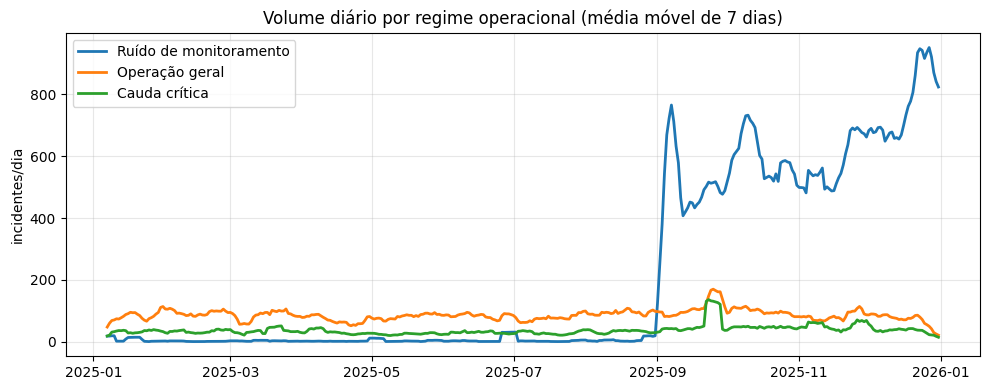

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
for nome in NOMES_CLUSTER.values():
    s = series[nome]
    ax.plot(s["data"], s["qtd_incidentes"].rolling(7).mean(), label=nome, lw=2)
ax.set_title("Volume diário por regime operacional (média móvel de 7 dias)")
ax.set_ylabel("incidentes/dia")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** as três séries têm dinâmicas diferentes. 

O ruído domina a escala e
muda de patamar em setembro/2025 (automação de monitoramento). 

Operação geral e cauda
crítica são mais estáveis em nível (tem trabalho humano)

## 5. Protocolo de avaliação

Para não escolher modelo olhando o teste (erro clássico em série temporal), a série é
partida em três blocos:

```
|<------------- treino ------------->|<-- validação rolling -->|<-- teste cego -->|
```

- **Validação rolling-origin:** 4 janelas de 30 dias dentro do treino. O modelo é
  retreinado a cada janela usando só o passado dela. O campeão é escolhido pelo MAE médio
  dessas janelas.
- **Teste:** os últimos 20% da série, nunca vistos durante a seleção.

**Candidatos.** Entram junto com os modelos de ML três estimadores ingênuos, e isso é
proposital: se um modelo de ML não bate "repetir ontem", ele não deveria ir para produção.

| Candidato | O que faz |
|---|---|
| `Naive_hoje` | repete o valor de hoje (persistência) |
| `Naive_lag_1` | repete o valor de ontem (convenção do `d1_d7.ipynb` original) |
| `Naive_media_7d` | repete a média dos últimos 7 dias |
| `Ridge` | regressão linear regularizada |
| `GradientBoosting` | configuração do `d1_d7.ipynb` original |
| `GB_huber` | boosting com perda robusta a outlier |
| `HistGB` e `RandomForest` | ensembles de árvore |
| `Ensemble` | média do melhor ML com o melhor ingênuo |

In [ ]:
MODELOS = {
    "Ridge": lambda: Ridge(alpha=1.0),
    "GradientBoosting": lambda: GradientBoostingRegressor(
        n_estimators=100, max_depth=4, learning_rate=0.03, random_state=SEED),
    "GB_huber": lambda: GradientBoostingRegressor(
        n_estimators=200, max_depth=2, learning_rate=0.03,
        loss="huber", random_state=SEED),
    "HistGB": lambda: HistGradientBoostingRegressor(
        max_iter=200, max_leaf_nodes=15, learning_rate=0.05,
        l2_regularization=1.0, random_state=SEED),
    "RandomForest": lambda: RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1),}

INGENUOS = {
    "Naive_hoje":     "qtd_incidentes",
    "Naive_lag_1":    "lag_1",
    "Naive_media_7d": "media_7d",}

CANDIDATOS = list(INGENUOS) + list(MODELOS)
N_FOLDS, TAM_FOLD = 4, 30

print(f"{len(CANDIDATOS)} candidatos + Ensemble | validação: {N_FOLDS} janelas de {TAM_FOLD} dias")

8 candidatos + Ensemble | validação: 4 janelas de 30 dias


### 5.1 Funções de previsão

`_fit_predict` resolve um candidato simples; `prever` é a porta de entrada e trata o
`Ensemble` à parte, porque ele precisa saber qual par (ML + ingênuo) está combinando.

Em todos os casos a previsão é cortada em zero: contagem de incidentes não é negativa, e
deixar o modelo prever −3 só piora o MAE.

In [15]:
def _fit_predict(nome, treino, alvo_df, target):
    """Previsão de um candidato simples (ingênuo ou modelo de ML)."""
    if nome == "Ensemble":
        raise ValueError("Ensemble é resolvido em prever(), não aqui")

    if nome in INGENUOS:
        return np.maximum(0, alvo_df[INGENUOS[nome]].values)

    modelo = MODELOS[nome]()
    modelo.fit(treino[FEATURES], treino[target])
    return np.maximum(0, modelo.predict(alvo_df[FEATURES]))


def prever(nome, treino, alvo_df, target, par_ensemble=None):
    """Porta de entrada: resolve qualquer candidato, inclusive o Ensemble."""
    if nome == "Ensemble":
        ml, naive = par_ensemble
        return (0.5 * _fit_predict(ml,    treino, alvo_df, target)
              + 0.5 * _fit_predict(naive, treino, alvo_df, target))
    return _fit_predict(nome, treino, alvo_df, target)

### 5.2 Validação rolling-origin

Cada janela corta o treino em um ponto diferente, treina só com o que vem antes e mede o
erro nos 30 dias seguintes. Janelas com menos de 60 dias de treino são descartadas — não
dá para aprender lag de 7 dias com menos que isso.

In [16]:
def mae_validacao(nome, treino_full, target, par_ensemble=None):
    """MAE médio nas janelas rolling-origin, dentro do treino."""
    erros = []
    for k in range(N_FOLDS, 0, -1):
        corte = len(treino_full) - k * TAM_FOLD
        if corte < 60:                       # janela de treino curta demais
            continue
        tr = treino_full.iloc[:corte]
        va = treino_full.iloc[corte:corte + TAM_FOLD]
        erros.append(mean_absolute_error(va[target],
                                         prever(nome, tr, va, target, par_ensemble)))
    return float(np.mean(erros)) if erros else np.inf

### 5.3 Métricas do teste

Além das métricas usuais, carrego sempre o **MAE da persistência** na mesma janela. É a
régua honesta: um MAE de 27 não quer dizer nada sozinho, mas 27 contra 19,8 da
persistência diz tudo.

O MAPE ignora os dias de valor zero — dividir por zero explodiria a métrica e daria a
impressão de erro infinito num dia em que simplesmente não houve incidente.

In [ ]:
def metricas(y, p, persistencia):
    """Métricas do teste, sempre acompanhadas da régua de persistência."""
    y = np.asarray(y, dtype=float)
    mask = y != 0
    return dict(
        MAE=mean_absolute_error(y, p),
        RMSE=float(np.sqrt(mean_squared_error(y, p))),
        R2=r2_score(y, p),
        MAPE=float(np.mean(np.abs((y[mask] - p[mask]) / y[mask])) * 100) if mask.any() else np.nan,
        MAE_persistencia=mean_absolute_error(y, np.maximum(0, persistencia)),)

### 5.4 A função que amarra tudo

`avaliar_serie` faz o ciclo completo para **uma** série e **um** horizonte: separa treino
e teste, roda a validação em todos os candidatos, monta o Ensemble com os melhores de
cada família, elege o campeão e só então toca no teste.

Ela devolve tudo que as seções seguintes precisam — por isso a tupla longa.

In [18]:
def avaliar_serie(serie: pd.DataFrame, target: str, rotulo: str, horizonte: str):
    """Ciclo completo de uma série: validação, escolha do campeão e teste cego.

    Devolve (linha_da_tabela, detalhe_do_teste, ranking_cv, par_ensemble, treino, serie_limpa).
    """
    sm = serie.dropna(subset=FEATURES + COLS_NAIVE + [target]).reset_index(drop=True)
    corte = int(len(sm) * (1 - FRAC_TESTE))
    treino_full, teste = sm.iloc[:corte], sm.iloc[corte:]

    # 1) validação de todos os candidatos, só com dados de treino
    cv = {candidato: mae_validacao(candidato, treino_full, target)
          for candidato in CANDIDATOS}

    # 2) Ensemble = média do melhor ML com o melhor ingênuo
    par = (min(MODELOS, key=cv.get), min(INGENUOS, key=cv.get))
    cv["Ensemble"] = mae_validacao("Ensemble", treino_full, target, par)

    # 3) campeão eleito pela validação — e só agora o teste é tocado
    campeao = min(cv, key=cv.get)
    pred = prever(campeao, treino_full, teste, target, par)
    met = metricas(teste[target].values, pred, teste["qtd_incidentes"].values)

    linha = {"cluster": rotulo, "horizonte": horizonte, "escolhido": campeao,
             "cv_MAE": cv[campeao], **met,
             "ganho_vs_persist_pct": (1 - met["MAE"] / met["MAE_persistencia"]) * 100}

    detalhe = pd.DataFrame({"data": teste["data"].values,
                            "real": teste[target].values,
                            "previsto": pred})
    return linha, detalhe, cv, par, treino_full, sm

## 6. Execução

Seis combinações (3 regimes × 2 horizontes), mais duas da série agregada, que serve de
termo de comparação.

Os resultados vão para cinco dicionários, usados nas seções seguintes:

| Objeto | Guarda |
|---|---|
| `tabela` | uma linha por combinação: campeão e métricas |
| `detalhes` | real × previsto, dia a dia, na janela de teste |
| `rankings` | MAE de validação de **todos** os candidatos |
| `pares` | qual par o Ensemble usou |
| `series_completas` | a série já limpa, para o retreino final |

In [19]:
tabela, detalhes, rankings, pares, series_completas = [], {}, {}, {}, {}

for rotulo in NOMES_CLUSTER.values():
    for target, horizonte in [("target_d1", "D+1"), ("target_d7", "D+7")]:
        linha, det, cv, par, _, sm = avaliar_serie(series[rotulo], target, rotulo, horizonte)

        tabela.append(linha)
        detalhes[(rotulo, horizonte)] = det
        rankings[(rotulo, horizonte)] = cv
        pares[(rotulo, horizonte)] = par
        series_completas[(rotulo, horizonte)] = sm

        print(f"{rotulo:24s} {horizonte}  campeão: {linha['escolhido']:16s} "
              f"cv_MAE {linha['cv_MAE']:7.2f} | teste MAE {linha['MAE']:7.2f} "
              f"(persistência {linha['MAE_persistencia']:7.2f})")

tabela = pd.DataFrame(tabela)

Ruído de monitoramento   D+1  campeão: Naive_hoje       cv_MAE   60.57 | teste MAE   99.71 (persistência   99.71)


Ruído de monitoramento   D+7  campeão: Ensemble         cv_MAE  105.64 | teste MAE  121.32 (persistência  131.07)


Operação geral           D+1  campeão: GB_huber         cv_MAE   22.38 | teste MAE   27.39 (persistência   29.00)


Operação geral           D+7  campeão: RandomForest     cv_MAE   22.43 | teste MAE   35.94 (persistência   27.63)


Cauda crítica            D+1  campeão: RandomForest     cv_MAE   14.61 | teste MAE   27.39 (persistência   19.83)


Cauda crítica            D+7  campeão: RandomForest     cv_MAE   15.14 | teste MAE   29.49 (persistência   23.79)


In [20]:
# mesma rotina na série agregada — é o modelo único que a decomposição precisa superar
detalhe_global = {}
for target, horizonte in [("target_d1", "D+1"), ("target_d7", "D+7")]:
    linha, det, cv, _, _, _ = avaliar_serie(serie_total, target, "SÉRIE TOTAL", horizonte)
    detalhe_global[horizonte] = det
    rankings[("SÉRIE TOTAL", horizonte)] = cv
    print(f"{'SÉRIE TOTAL':24s} {horizonte}  campeão: {linha['escolhido']:16s} "
          f"cv_MAE {linha['cv_MAE']:7.2f} | teste MAE {linha['MAE']:7.2f}")

SÉRIE TOTAL              D+1  campeão: Naive_hoje       cv_MAE  104.82 | teste MAE  122.38


SÉRIE TOTAL              D+7  campeão: Ensemble         cv_MAE  131.98 | teste MAE  123.16


## 7. Resultados

### 7.1 Campeão de cada combinação

In [21]:
COLS_TABELA = ["cluster", "horizonte", "escolhido", "cv_MAE", "MAE", "RMSE", "R2",
               "MAPE", "MAE_persistencia", "ganho_vs_persist_pct"]
tabela[COLS_TABELA].round(2)

,cluster,horizonte,escolhido,cv_MAE,MAE,RMSE,R2,MAPE,MAE_persistencia,ganho_vs_persist_pct
0,Ruído de monitoramento,D+1,Naive_hoje,60.57,99.71,145.57,0.27,14.68,99.71,0.00
1,Ruído de monitoramento,D+7,Ensemble,105.64,121.32,169.21,0.02,16.79,131.07,7.44
2,Operação geral,D+1,GB_huber,22.38,27.39,36.89,0.07,68.69,29.00,5.57
3,Operação geral,D+7,RandomForest,22.43,35.94,45.71,-0.43,83.93,27.63,-30.07
4,Cauda crítica,D+1,RandomForest,14.61,27.39,38.40,-1.40,108.94,19.83,-38.09
5,Cauda crítica,D+7,RandomForest,15.14,29.49,45.85,-2.37,119.85,23.79,-23.97


### 7.2 Ranking completo da validação

Esta é a tabela que sustenta o argumento do notebook: quanto **cada** candidato errou na
validação, em **cada** regime. É aqui que fica visível onde o aprendizado de máquina
agrega e onde ele só atrapalha.

In [22]:
rank_df = (pd.DataFrame(rankings).T
             .rename_axis(["cluster", "horizonte"])
             .round(1)
             .sort_index())
rank_df

Naive_hoje  Naive_lag_1  Naive_media_7d  Ridge  GradientBoosting  GB_huber  HistGB  RandomForest  Ensemble
cluster                horizonte                                                                                                            
Cauda crítica          D+1              21.3         25.4            20.2   17.4              15.2      14.7    14.9          14.6      16.6
                       D+7              22.2         24.0            20.7   16.4              16.2      15.1    16.1          15.1      16.9
Operação geral         D+1              37.8         54.4            36.6   32.2              24.5      22.4    23.0          22.5      27.5
                       D+7              30.2         43.5            36.8   25.9              24.5      22.5    23.4          22.4      24.7
Ruído de monitoramento D+1              60.6         76.2            80.5  128.5             135.2     138.0   138.3         132.4      81.6
                       D+7             110.5        117.0           107.7  134.6             139.8     134.1   134.9         133.9     105.6
SÉRIE TOTAL            D+1             104.8        137.7           120.5  143.9             164.1     164.0   150.2         154.1     109.5
                       D+7             142.0        163.6           140.8  159.2             165.3     159.7   161.9         157.0     132.0

In [23]:
# quanto o melhor ML supera (ou perde para) o melhor ingênuo, na validação
linhas = []
for (rotulo, horizonte), cv in rankings.items():
    m_ml = min(MODELOS,  key=lambda n: cv[n])
    m_nv = min(INGENUOS, key=lambda n: cv[n])
    linhas.append(dict(cluster=rotulo, horizonte=horizonte,
                       melhor_ML=m_ml,      MAE_ML=cv[m_ml],
                       melhor_ingenuo=m_nv, MAE_ingenuo=cv[m_nv],
                       ganho_ML_pct=(1 - cv[m_ml] / cv[m_nv]) * 100))

comparativo = pd.DataFrame(linhas).sort_values(["horizonte", "cluster"])
comparativo.round(1)

,cluster,horizonte,melhor_ML,MAE_ML,melhor_ingenuo,MAE_ingenuo,ganho_ML_pct
4,Cauda crítica,D+1,RandomForest,14.6,Naive_media_7d,20.2,27.6
2,Operação geral,D+1,GB_huber,22.4,Naive_media_7d,36.6,38.8
0,Ruído de monitoramento,D+1,Ridge,128.5,Naive_hoje,60.6,-112.2
6,SÉRIE TOTAL,D+1,Ridge,143.9,Naive_hoje,104.8,-37.3
5,Cauda crítica,D+7,RandomForest,15.1,Naive_media_7d,20.7,26.9
3,Operação geral,D+7,RandomForest,22.4,Naive_hoje,30.2,25.8
1,Ruído de monitoramento,D+7,RandomForest,133.9,Naive_media_7d,107.7,-24.3
7,SÉRIE TOTAL,D+7,RandomForest,157.0,Naive_media_7d,140.8,-11.5


**Como ler `ganho_ML_pct`:** positivo é o ML errando **menos** que o ingênuo (o ML ganha);
negativo é o ML errando **mais** — e aí quem vai para produção é o estimador simples.

### 7.3 Decomposição contra o modelo único

Somar as três previsões de cluster reconstrói o total. Comparo essa soma com o modelo
global treinado na série agregada, nos mesmos dias — porque não adianta a decomposição ser
mais informativa se ela for menos precisa.

In [24]:
for horizonte in ["D+1", "D+7"]:
    soma = None
    for nome in NOMES_CLUSTER.values():
        d = detalhes[(nome, horizonte)].set_index("data")
        soma = d if soma is None else soma.add(d, fill_value=0)

    j = soma.join(detalhe_global[horizonte].set_index("data"),
                  how="inner", rsuffix="_global").dropna()

    mae_soma   = mean_absolute_error(j["real"], j["previsto"])
    mae_global = mean_absolute_error(j["real_global"], j["previsto_global"])
    print(f"{horizonte} | dias avaliados: {len(j)}")
    print(f"   soma dos 3 clusters : MAE {mae_soma:7.2f}")
    print(f"   modelo único global : MAE {mae_global:7.2f}")
    print(f"   diferença           : {mae_global - mae_soma:+7.2f} a favor da "
          f"{'decomposição' if mae_soma < mae_global else 'série única'}\n")

D+1 | dias avaliados: 72
   soma dos 3 clusters : MAE  120.50
   modelo único global : MAE  122.38
   diferença           :   +1.87 a favor da decomposição

D+7 | dias avaliados: 71
   soma dos 3 clusters : MAE  123.75
   modelo único global : MAE  123.16
   diferença           :   -0.59 a favor da série única



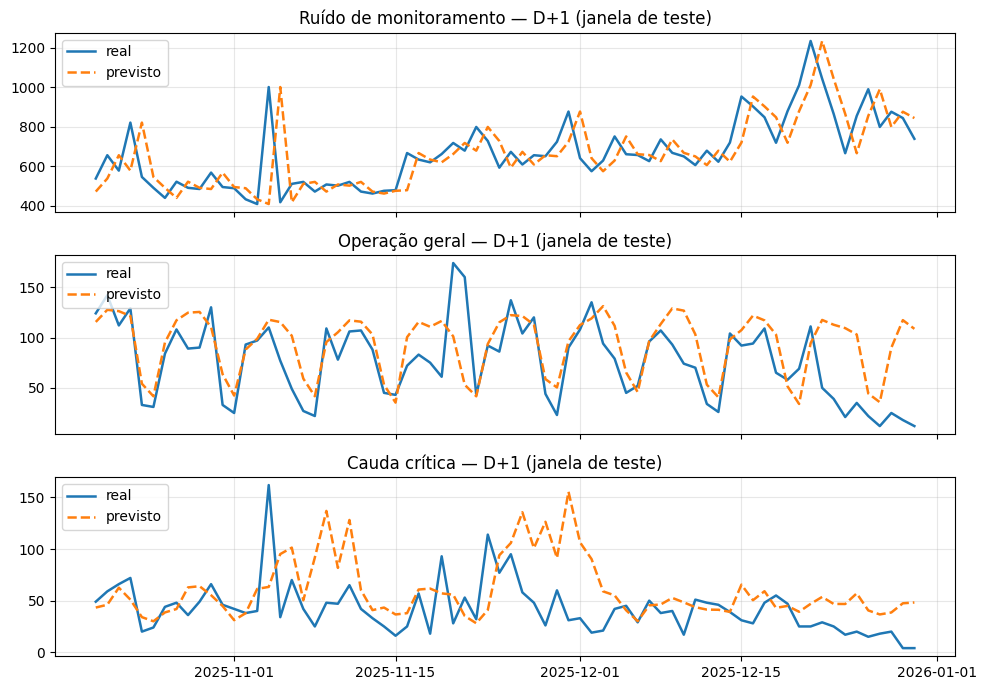

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, nome in zip(axes, NOMES_CLUSTER.values()):
    d = detalhes[(nome, "D+1")]
    ax.plot(d["data"], d["real"], label="real", lw=1.8)
    ax.plot(d["data"], d["previsto"], label="previsto", lw=1.8, ls="--")
    ax.set_title(f"{nome} — D+1 (janela de teste)")
    ax.legend(loc="upper left")
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

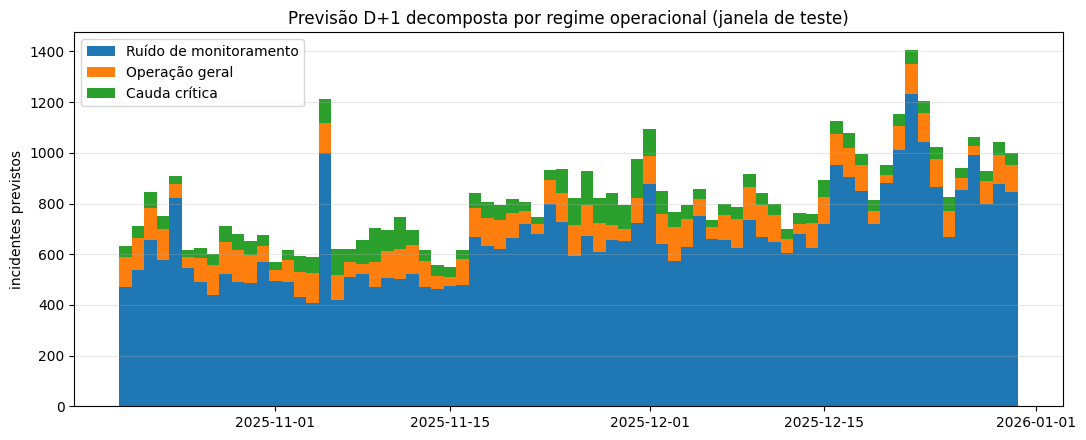

In [26]:
fig, ax = plt.subplots(figsize=(11, 4.5))
acum = None
for nome in NOMES_CLUSTER.values():
    d = detalhes[(nome, "D+1")].set_index("data")["previsto"]
    ax.bar(d.index, d.values, bottom=acum, label=nome, width=1.0)
    acum = d.values if acum is None else acum + d.values
ax.set_title("Previsão D+1 decomposta por regime operacional (janela de teste)")
ax.set_ylabel("incidentes previstos")
ax.legend()
ax.grid(alpha=.3, axis="y")
plt.tight_layout()
plt.show()

## 8. A saída que vai para a operação

O produto final não é uma métrica: são **três números com dono**. Aqui o campeão de cada
combinação é retreinado na série completa e projeta o próximo dia e a próxima semana.

O último dia da série tem todas as features conhecidas (`lag_1`, `lag_7`, `media_7d`), então
é dele que sai a projeção de `t+1` e `t+7`.

In [27]:
previsao_final = []
for rotulo in NOMES_CLUSTER.values():
    for target, horizonte in [("target_d1", "D+1"), ("target_d7", "D+7")]:
        sm      = series_completas[(rotulo, horizonte)]
        campeao = tabela.query("cluster == @rotulo and horizonte == @horizonte")["escolhido"].iloc[0]
        par     = pares[(rotulo, horizonte)]

        ultimo = series[rotulo].dropna(subset=FEATURES + COLS_NAIVE).iloc[[-1]]
        valor  = prever(campeao, sm, ultimo, target, par)[0]
        data_alvo = ultimo["data"].iloc[0] + pd.Timedelta(days=1 if horizonte == "D+1" else 7)

        previsao_final.append(dict(cluster=rotulo, horizonte=horizonte,
                                   data_referencia=ultimo["data"].iloc[0].date(),
                                   data_prevista=data_alvo.date(),
                                   incidentes_previstos=int(round(valor)),
                                   modelo=campeao))

previsao_final = pd.DataFrame(previsao_final)
previsao_final

,cluster,horizonte,data_referencia,data_prevista,incidentes_previstos,modelo
0,Ruído de monitoramento,D+1,2025-12-31,2026-01-01,739,Naive_hoje
1,Ruído de monitoramento,D+7,2025-12-31,2026-01-07,806,Ensemble
2,Operação geral,D+1,2025-12-31,2026-01-01,32,GB_huber
3,Operação geral,D+7,2025-12-31,2026-01-07,54,RandomForest
4,Cauda crítica,D+1,2025-12-31,2026-01-01,17,RandomForest
5,Cauda crítica,D+7,2025-12-31,2026-01-07,28,RandomForest


In [28]:
for horizonte in ["D+1", "D+7"]:
    bloco = previsao_final.query("horizonte == @horizonte")
    total = bloco["incidentes_previstos"].sum()
    data  = bloco["data_prevista"].iloc[0]

    print(f"\n=== PREVISÃO {horizonte} — {data} ===")
    print(f"TOTAL: {total} incidentes\n")
    for _, r in bloco.iterrows():
        pct = r["incidentes_previstos"] / total * 100
        barra = "#" * int(pct / 2)
        print(f"  {r['cluster']:24s} {r['incidentes_previstos']:5d}  ({pct:4.1f}%)  {barra}")

    humano = bloco.query("cluster != 'Ruído de monitoramento'")["incidentes_previstos"].sum()
    print(f"\n  -> exigem atuação humana: {humano} de {total} ({humano / total * 100:.1f}%)")


=== PREVISÃO D+1 — 2026-01-01 ===
TOTAL: 788 incidentes

  Ruído de monitoramento     739  (93.8%)  ##############################################
  Operação geral              32  ( 4.1%)  ##
  Cauda crítica               17  ( 2.2%)  #

  -> exigem atuação humana: 49 de 788 (6.2%)

=== PREVISÃO D+7 — 2026-01-07 ===
TOTAL: 888 incidentes

  Ruído de monitoramento     806  (90.8%)  #############################################
  Operação geral              54  ( 6.1%)  ###
  Cauda crítica               28  ( 3.2%)  #

  -> exigem atuação humana: 82 de 888 (9.2%)


## 9. Exportação para a plataforma PredictOps

Três arquivos, nos schemas que o app já espera (ver `data_prep.py`):

| Arquivo | Tabela no BigQuery | Consumido por |
|---|---|---|
| `clusters_incidentes.csv` | `predictops_gold.clusters_incidentes` | Jornal de Turno, Painel NOC, Painel Gerencial |
| `previsao_d1_por_cluster.csv` | `predictops_gold.previsao_d1_por_cluster` | Painel NOC, Painel Gerencial |
| `previsao_d7_por_cluster.csv` | `predictops_gold.previsao_d7_por_cluster` | Painel NOC, Painel Gerencial |
| `metricas_previsao_por_cluster.csv` | `predictops_gold.metricas_previsao_por_cluster` | aba Confiança dos Modelos |

**Detalhe do schema:** as previsões saem com a coluna `origem`, que separa `backtest`
(janela de teste, tem `real` preenchido) de `projecao` (futuro, `real` vazio). É isso que
permite ao painel desenhar a faixa de confiança e a linha do futuro no mesmo gráfico.

A coluna do modelo vencedor chama `escolhido` — é o nome que o `data_prep.metricas_cluster()`
procura. Renomear isso quebra a tela de confiança dos modelos sem dar erro.

In [29]:
# 1) rótulo de cluster por incidente
(df[["Número", "cluster", "cluster_nome"]]
   .rename(columns={"Número": "numero_incidente"})
   .to_csv(SAIDA / "clusters_incidentes.csv", index=False, encoding="utf-8-sig"))
print(f"{'clusters_incidentes.csv':36s} {len(df):5d} linhas")

# 2) previsões por cluster: backtest + projeção, no mesmo arquivo
for horizonte, arquivo in [("D+1", "previsao_d1_por_cluster.csv"),
                           ("D+7", "previsao_d7_por_cluster.csv")]:
    partes = []
    for nome in NOMES_CLUSTER.values():
        d = detalhes[(nome, horizonte)].copy()
        d["cluster"], d["horizonte"], d["origem"] = nome, horizonte, "backtest"
        partes.append(d)
    hist = pd.concat(partes, ignore_index=True)

    fut = (previsao_final.query("horizonte == @horizonte")
             .rename(columns={"data_prevista": "data", "incidentes_previstos": "previsto"})
             [["data", "previsto", "cluster", "horizonte"]])
    fut["real"] = np.nan
    fut["origem"] = "projecao"

    out = pd.concat([hist, fut], ignore_index=True)
    out["previsto"] = out["previsto"].round(0).astype(int)
    out = out[["data", "cluster", "horizonte", "previsto", "real", "origem"]]
    out.to_csv(SAIDA / arquivo, index=False, encoding="utf-8-sig")
    print(f"{arquivo:36s} {len(out):5d} linhas")

# 3) métricas, para a tela de confiança dos modelos
tabela[COLS_TABELA].round(3).to_csv(SAIDA / "metricas_previsao_por_cluster.csv",
                                    index=False, encoding="utf-8-sig")
print(f"{'metricas_previsao_por_cluster.csv':36s} {len(tabela):5d} linhas")

clusters_incidentes.csv              122543 linhas
previsao_d1_por_cluster.csv            219 linhas
previsao_d7_por_cluster.csv            216 linhas
metricas_previsao_por_cluster.csv        6 linhas


## 10. Conclusões

### O que a decomposição entrega

A previsão deixa de ser um número agregado e passa a responder **quem precisa agir**.
O bloco da seção 8 é o que vai para a tela do gestor: o total, a quebra por regime e,
principalmente, quantos incidentes exigem pessoa — cerca de 6% em D+1 e 9% em D+7 do
volume bruto que a operação enxerga. Nenhum modelo de série única produz essa informação:
ele devolve um número que ninguém sabe dividir.

### O que os números dizem sobre a hipótese

O ranking da seção 7.2 mostra um padrão consistente, e ele é o achado técnico do notebook:

| Regime | Melhor ML (validação) | Melhor ingênuo | `ganho_ML_pct` |
|---|---|---|---|
| Operação geral D+1 | GB_huber 22,4 | Naive_media_7d 36,6 | **+38,8%** — ML ganha |
| Cauda crítica D+1 | RandomForest 14,6 | Naive_media_7d 20,2 | **+27,6%** — ML ganha |
| Ruído de monitoramento D+1 | Ridge 128,5 | Naive_hoje 60,6 | **−112%** — ML perde feio |
| Série total D+1 | Ridge 143,9 | Naive_hoje 104,8 | **−37%** — ML perde |

A leitura: **o ML só aprende onde existe padrão de demanda humana.** O ruído é dirigido por
mudanças de configuração de monitoramento — não há sazonalidade a capturar, só nível a
acompanhar, e um estimador simples faz isso melhor. Como o ruído é 63% do volume, ele
contamina a série agregada e derruba qualquer modelo treinado nela.

Separando os regimes, cada um recebe o estimador adequado — e a escolha passa a ser
justificada por validação, não por preferência.

### A decomposição custa precisão?

Não. Em D+1 a soma das três previsões dá MAE 120,50 contra 122,38 do modelo único, nos
mesmos 72 dias. Em D+7 as duas praticamente empatam (123,75 contra 123,16, diferença de
0,6 incidente por dia).

Ou seja: **o mesmo nível de erro, com três números acionáveis no lugar de um número cego.**
É esse o argumento — não um ganho de MAE.

### Ressalva honesta sobre a janela de teste

O período de teste (nov–dez/2025) contém uma quebra de regime: os incidentes de saturação
de recurso saltam de cerca de 2.100 em novembro para 10.900 em dezembro. Nessa janela, os
modelos escolhidos na validação perdem para a persistência nos clusters menores — Cauda
crítica D+1 fica com MAE 27,4 contra 19,8 da persistência, e Operação geral D+7 com 35,9
contra 27,6. É o comportamento esperado quando a distribuição muda depois do treino.

Isso não invalida a decomposição; aponta duas ações concretas:

1. **Retreino periódico com monitoramento de drift**, em vez de modelo congelado. O próprio
   protocolo deste notebook (validação rolling-origin) já é o mecanismo de reseleção.
2. **Investigar dezembro:** um salto de 5× em saturação de recurso é monitor novo ligado ou
   capacidade real acabando — e as duas respostas geram ação operacional.

Declarar isso na apresentação é mais forte do que esconder: mostra que a equipe sabe
distinguir erro de modelo de mudança de ambiente.